## Geometries Exercise

Laurent wants to buy a house in Sierre. He went to visit 3 properties and he collected the coordinates in this file: data/simple-geometries/exercise-geometries.txt

### 1. Read the text file

In [93]:
f = open ('../../data/simple-geometries/exercise-geometries.txt')

### 2. Explore the file contents

The file contains coordinates of: terrains, houses, swimming pool, river, road, university and train station.

In [94]:
data = f.readlines()
data[:4]

['geo;terrain;T-A;7.535770833492279,46.29209752598038;7.535832524299621,46.29196223064501;7.536106109619141,46.29214756663618;7.5359907746315,46.29223652768917;7.535816431045532,46.29220872737563;7.535770833492279,46.29209752598038\n',
 'geo;terrain;T-B;7.536124885082244,46.29241630270935;7.5362858176231375,46.29220316731123;7.536532580852508,46.29243668953004;7.536296546459199,46.29272210422308;7.536073923110961,46.29255715695201;7.536124885082244,46.29241630270935\n',
 'geo;terrain;C;7.535186111927033,46.291632331028985;7.535373866558075,46.29152298184133;7.535583078861236,46.29157302302211;7.535566985607147,46.291758360330334;7.535186111927033,46.291632331028985\n',
 'geo;river;Smallriver;7.536556720733643,46.292848131016726;7.536454796791076,46.29264797067957;7.536409199237823,46.29244039622391;7.536098062992096,46.29238850248708;7.536098062992096,46.292262474635734;7.535937130451202,46.29220502066609;7.535741329193115,46.29213829985153;7.535062730312348,46.29170275920373\n']

### 3. Create geometries for each type of object in the file

`Polygon` for terrains,houses, pool. `LineString` for river, road, `Point` for station and university.

In [ ]:
from shapely.geometry import Polygon
from shapely.geometry import LineString
from shapely.geometry import Point
from shapely.geometry import GeometryCollection
    

In [96]:
class GeoObject(object):    
    def __init__(self,line):
       line=line.split(';')
       self.name=line[2]
       self.objectType=line[1]
       coords=[]
       for c in line[3:]:
          (x,y)=c.split(',')
          coords.append((float(x),float(y)))
       self.createGeometry(coords)
       
    def createGeometry(self,coords):
       objType=self.objectType
       if (objType == 'terrain' or objType=='house' or objType=='pool'):
          self.geom=Polygon(coords)
       elif (objType == 'river' or objType=='road'):
          self.geom=LineString(coords)
       else:
          self.geom=Point(coords)

geometries=[GeoObject(line.strip()) for line in data]
geometries

### 4. Which is the larger house? H1, H2, H3?

In [101]:
houses = [g for g in geometries if g.objectType=='house']
bigHouse = max(houses,key=lambda h:h.geom.area)
bigHouse.name

'H3'

In [103]:
max=0
for h in houses:
   if h.geom.area>max:
      max=h.geom.area
      bigger=h
bigger.name

'H3'

### 5. Which house is contained in which terrain?

In [105]:
match={}
terrains = [g for g in geometries if g.objectType=='terrain']
for t in terrains:
    for h in houses:
        if h.geom.within(t.geom):
          match[t.name]=h.name

match

{'T-A': 'H1', 'T-B': 'H3', 'C': 'H2'}

### 6. Which terrain is closer to the road? and to the university?

In [115]:
roads=filter(lambda r:r.objectType=='road' ,geometries)
road=list(roads)[0]

unis=filter(lambda r:r.objectType=='university' ,geometries)
uni=list(unis)[0]

minDist=100000
for t in terrains:
    dist=t.geom.distance(road.geom)
    if dist<minDist :
       minDist=dist
       closer=t

closer.name

'T-B'

In [116]:
minDist=100000
for t in terrains:
    dist=t.geom.distance(uni.geom)
    if dist<minDist :
       minDist=dist
       closer=t

closer.name

'T-B'

### 7. The subterranean river crosses some terrains. Which ones?

In [118]:
rivers=filter(lambda r:r.objectType=='river' ,geometries)
river=list(rivers)[0]

for t in terrains:
    if t.geom.intersects(river.geom):
      print(t.name)


T-A
T-B


In [119]:
for t in terrains:
    if river.geom.crosses(t.geom):
      print(t.name)


T-A
T-B


### 8. Which terrain has a swimming pool?

In [120]:
pools=filter(lambda r:r.objectType=='pool' ,geometries)
pool=list(pools)[0]

for t in terrains:
    if t.geom.contains(pool.geom):
      print(t.name)


T-B


### 9. Create a new geometry for a terrain without the surface of the house and swimming pool

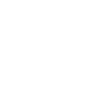

In [121]:
terrainB=list(filter(lambda r:r.name=='T-B',terrains))[0]
house3=list(filter(lambda r:r.name=='H3',houses))[0]

newTerrain=terrainB.geom.difference(house3.geom)
newTerrain=newTerrain.difference(pool.geom)

newTerrain


#### 10. Compute the area of a terrain. Is it correct? How about the area of a house?

In [123]:
terrainB.geom.area

house3.geom.area

1.6777327122259985e-08

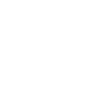

In [125]:
housesGeom = [g.geom for g in houses]

gcol = GeometryCollection(housesGeom[:])
gcol

